# Merge Cell Label Annotations

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [33]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import session_info
import sys

In [34]:
sys.path.append(str(Path.cwd().resolve().parents[1]))

from config.paths import BASE_DIR

# Data directories
input_dir = BASE_DIR / "data/h5ad/export_02/02a_scvi"
adata_path = input_dir / "ModelA_475_adata-scvi.h5ad"
seurat_labels_path = BASE_DIR / "data/rds/seurat/label_transfer_xenium.csv"

output_dir = BASE_DIR / "data/h5ad/export_03/03a_seurat"

In [35]:
adata = sc.read_h5ad(adata_path)
seurat_df = pd.read_csv(seurat_labels_path)
# manual_df = pd.read_csv(manual_annotations_path)

# Seurat label transfer annotations

In [36]:
# Make a copy and set cell barcodes as index
labels = seurat_df.copy()
labels.index = labels["Unnamed: 0"]
labels = labels.drop(columns=["Unnamed: 0"])

# Keep rows present in adata, reindex
shared = labels.index.intersection(adata.obs_names)
labels = labels.loc[shared]
labels = labels.reindex(adata.obs_names)

# Add columns to adata
adata.obs = adata.obs.join(labels)

In [37]:
adata.obs['cell_type'] = adata.obs['predicted.id']

In [38]:
adata.obs

,cell_id,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,...,prediction.score.Vascular_endothelial_2,prediction.score.Macrophage_1,prediction.score.Cycling.SGC,prediction.score.Pericyte,prediction.score.Macrophage_2,prediction.score.Fibroblast_2,prediction.score.Angiogenic.EC,prediction.score.Fibroblast_1,prediction.score.max,cell_type
aaaacmnk-1-0,aaaacmnk-1,226.557434,3029.284180,80,0,0,0,0,0,80.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.784352,SGC
aaababeb-1-0,aaababeb-1,271.645538,3121.138428,242,0,0,0,0,0,242.0,...,0.057433,0.000000,0.0,0.050244,0.000000,0.028384,0.000000,0.588530,0.588530,Fibroblast_1
aaaegioj-1-0,aaaegioj-1,300.646088,3117.702881,141,0,0,0,0,0,141.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.919393,Schwann_cell
aadidbcn-1-0,aadidbcn-1,251.569107,3279.324219,131,0,0,0,0,0,131.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.591246,SGC
aaeepbcc-1-0,aaeepbcc-1,371.284851,3147.021484,90,0,0,0,0,0,90.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,Schwann_cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ohpdlnah-1-3,ohpdlnah-1,3956.741699,3115.638916,78,0,0,0,0,0,78.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.930492,0.000000,0.069508,0.930492,Fibroblast_2
ohpedfnp-1-3,ohpedfnp-1,3992.232178,3120.251221,71,0,0,0,0,0,71.0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.901401,0.000000,0.098599,0.901401,Fibroblast_2
oicbjhcp-1-3,oicbjhcp-1,5897.502441,758.368774,70,0,0,0,0,0,70.0,...,0.022104,0.000000,0.0,0.000000,0.000000,0.197218,0.000000,0.770973,0.770973,Fibroblast_1
oieanihb-1-3,oieanihb-1,5898.719238,1169.679932,58,0,0,0,0,0,58.0,...,0.000000,0.095187,0.0,0.000000,0.894391,0.000000,0.000000,0.000000,0.894391,Macrophage_2


### Neuronal vs. Rest 

In [39]:
adata.obs['cell_type'].unique().tolist()

['SGC',
 'Fibroblast_1',
 'Schwann_cell',
 'Macrophage_1',
 'Nonpeptidergic nociceptors',
 'Abeta-RA-LTMR',
 'Proprioceptors',
 'Adelta-LTMR',
 'CGRP-Epsilion',
 'CGRP-Eta',
 'CGRP-Zeta',
 'C-LTMR',
 'CGRP-Alpha',
 'Abeta-Field',
 'Fibroblast_2',
 'CGRP-Theta',
 'CGRP-Gamma',
 'TrpM8',
 'Sst',
 'CGRP-Beta',
 'Pericyte',
 'Vascular_endothelial_1',
 'Vascular_endothelial_2',
 'Macrophage_2',
 nan,
 'Angiogenic EC',
 'Cycling SGC']

In [40]:
cols = ["cell_type"]

for col in cols:
    adata.obs[col] = adata.obs[col].astype("category")
    adata.obs[col] = adata.obs[col].cat.rename_categories({"Macrophage_2": "Mixed"}) # Mixed hematopoeitic population
    adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

In [41]:
label_to_class = {
    # Neurons
    "CGRP-Gamma": "Neuron",
    "CGRP-Eta": "Neuron",
    "CGRP-Zeta": "Neuron",
    "CGRP-Theta": "Neuron",
    "CGRP-Epsilion": "Neuron",
    "CGRP-Alpha": "Neuron",
    "CGRP-Beta": "Neuron",
    "Nonpeptidergic nociceptors": "Neuron",
    "Abeta-RA-LTMR": "Neuron",
    "Abeta-Field": "Neuron",
    "Adelta-LTMR": "Neuron",
    "C-LTMR": "Neuron",
    "TrpM8": "Neuron",
    "Proprioceptors": "Neuron",
    "Sst": "Neuron",
    
    # Non-neurons
    "Schwann_cell": "Non-neuron",
    "SGC": "Non-neuron",
    "Mixed": "Non-neuron",
    "Vascular_endothelial_1": "Non-neuron",
    "Vascular_endothelial_2": "Non-neuron",
    "Fibroblast_1": "Non-neuron",
    "Fibroblast_2": "Non-neuron",
    "Macrophage_1": "Non-neuron",
    "Pericyte": "Non-neuron",
    "Angiogenic EC": "Non-neuron",
    "Cycling SGC": "Non-neuron",
    "Unassigned": "Non-neuron",
}

In [42]:
for src, dst in [("cell_type", "cell_class")]:
    adata.obs[dst] = adata.obs[src].map(label_to_class).astype("category")

In [43]:
# Count total and neuron fraction
counts = adata.obs["cell_class"].value_counts()

neuron_count = counts.get("Neuron", 0)
total = counts.sum()
non_neuron_count = total - neuron_count

# Percentages
labels = ["Neuron", "Non-neuron"]
values = [(neuron_count / total) * 100, (non_neuron_count / total) * 100]

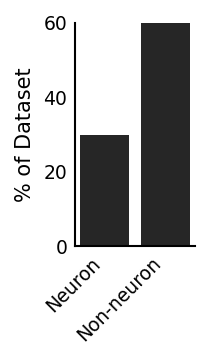

In [44]:
# Plot neuronal vs. rest breakdown
plt.figure(figsize=(1.5, 2.5), dpi=150)
plt.bar(labels, values, color=["black", "black"], alpha=0.85)

plt.ylim(0, 60)
plt.ylabel("% of Dataset", fontsize=10)
plt.xlabel("")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(fontsize=9)

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)

plt.tight_layout()
plt.show()

## Run umap on this global dataset (MC didn't do this?)

In [52]:
# first run through on unfiltered dataset
print('neighbors')
sc.pp.neighbors(adata, use_rep = 'X_scVI_ModelA_475', random_state = 0)
print('umap')
sc.tl.umap(adata, random_state = 0)
# sc.tl.leiden(adata, key_added='global_leiden', resolution=0.25)

neighbors
umap


In [56]:
plt.rcParams['figure.figsize'] = (3, 3)

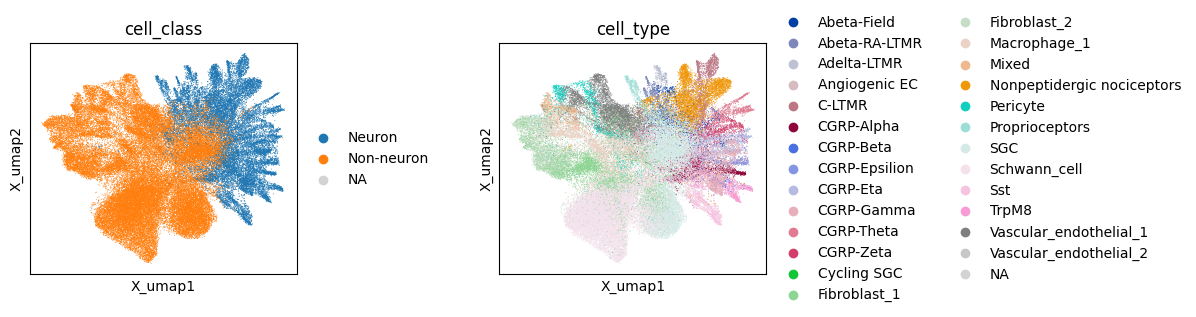

In [59]:
sc.pl.embedding(adata, basis = 'X_umap', color = ['cell_class', 'cell_type'], wspace = 0.6)

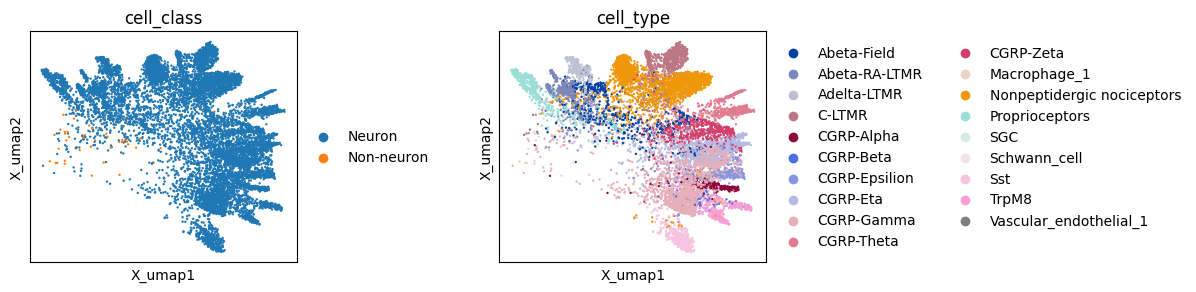

In [60]:
sc.pl.embedding(adata[adata.obs['total_counts']>1000, :], basis = 'X_umap', color = ['cell_class', 'cell_type'], wspace = 0.6)

## Export

In [47]:
filename = os.path.join(output_dir, "adata-merged-labels.h5ad")
os.makedirs(os.path.dirname(filename), exist_ok=True)

adata.write_h5ad(filename, compression='gzip')

In [48]:
adata

AnnData object with n_obs × n_vars = 72778 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'predicted.id', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'prediction.score.Adelta.LTMR', 'prediction.

In [50]:
filename

'/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad'

In [ ]:
/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/h5ad/export_03/03a_seurat/adata-merged-labels.h5ad